# Spotify Top Songs (2010-2019) — Popularity Prediction

**Techolas Technologies — Machine Learning Internship Project**

**Author:** [Your Name]  **Date:** August 2026

This notebook builds a regression pipeline that predicts a song's Spotify
**popularity score (0-100)** from its audio features (tempo, energy,
danceability, loudness, liveness, valence, duration, acousticness,
speechiness), release year, and genre.

**Dataset:** "Top Spotify Songs from 2010-2019, by year" — 603 tracks, 15
columns, sourced from Kaggle (mirrored via Zenodo, CC-BY 4.0). Every row is
one song that appeared in Spotify's year-end Top 10s playlist for 2010-2019.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

## 2. Data Understanding

In [2]:
df = pd.read_csv("data/top10s.csv")
df = df.rename(columns={
    "Unnamed: 0": "id", "top genre": "genre", "bpm": "tempo", "nrgy": "energy",
    "dnce": "danceability", "dB": "loudness", "live": "liveness", "val": "valence",
    "dur": "duration", "acous": "acousticness", "spch": "speechiness", "pop": "popularity"
})
df = df.drop(columns=["id"])
df.head()

   title                artist            genre  year  tempo  energy  danceability  loudness  liveness  valence  duration  acousticness  speechiness  popularity
0  Hey, Soul Sister    Train       neo mellow  2010     97      89            67        -4         8       80       217            19            4          83
1  Love The Way You Lie  Eminem  detroit hip hop  2010     87      93            75        -5        52       64       263            24           23          82
...  (603 rows x 14 columns)

In [3]:
df.shape

(603, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         603 non-null    object
 1   artist        603 non-null    object
 2   genre         603 non-null    object
 3   year          603 non-null    int64 
 4   tempo         603 non-null    int64 
 5   energy        603 non-null    int64 
 6   danceability  603 non-null    int64 
 7   loudness      603 non-null    int64 
 8   liveness      603 non-null    int64 
 9   valence       603 non-null    int64 
 10  duration      603 non-null    int64 
 11  acousticness  603 non-null    int64 
 12  speechiness   603 non-null    int64 
 13  popularity    603 non-null    int64 
dtypes: int64(11), object(3)
memory usage: 66.1+ KB


In [5]:
df.isnull().sum().sum()  # check for missing values

0

In [6]:
df.describe().round(2)

(summary statistics — see printed table for mean/std/min/25%/50%/75%/max of every numeric column)

In [7]:
print("Unique artists:", df['artist'].nunique())
print("Unique genres  :", df['genre'].nunique())
print("Duplicate song titles:", df['title'].duplicated().sum())

Unique artists: 184
Unique genres  : 50
Duplicate song titles: 19


## 3. Exploratory Data Analysis

### 3.1 Correlation Heatmap

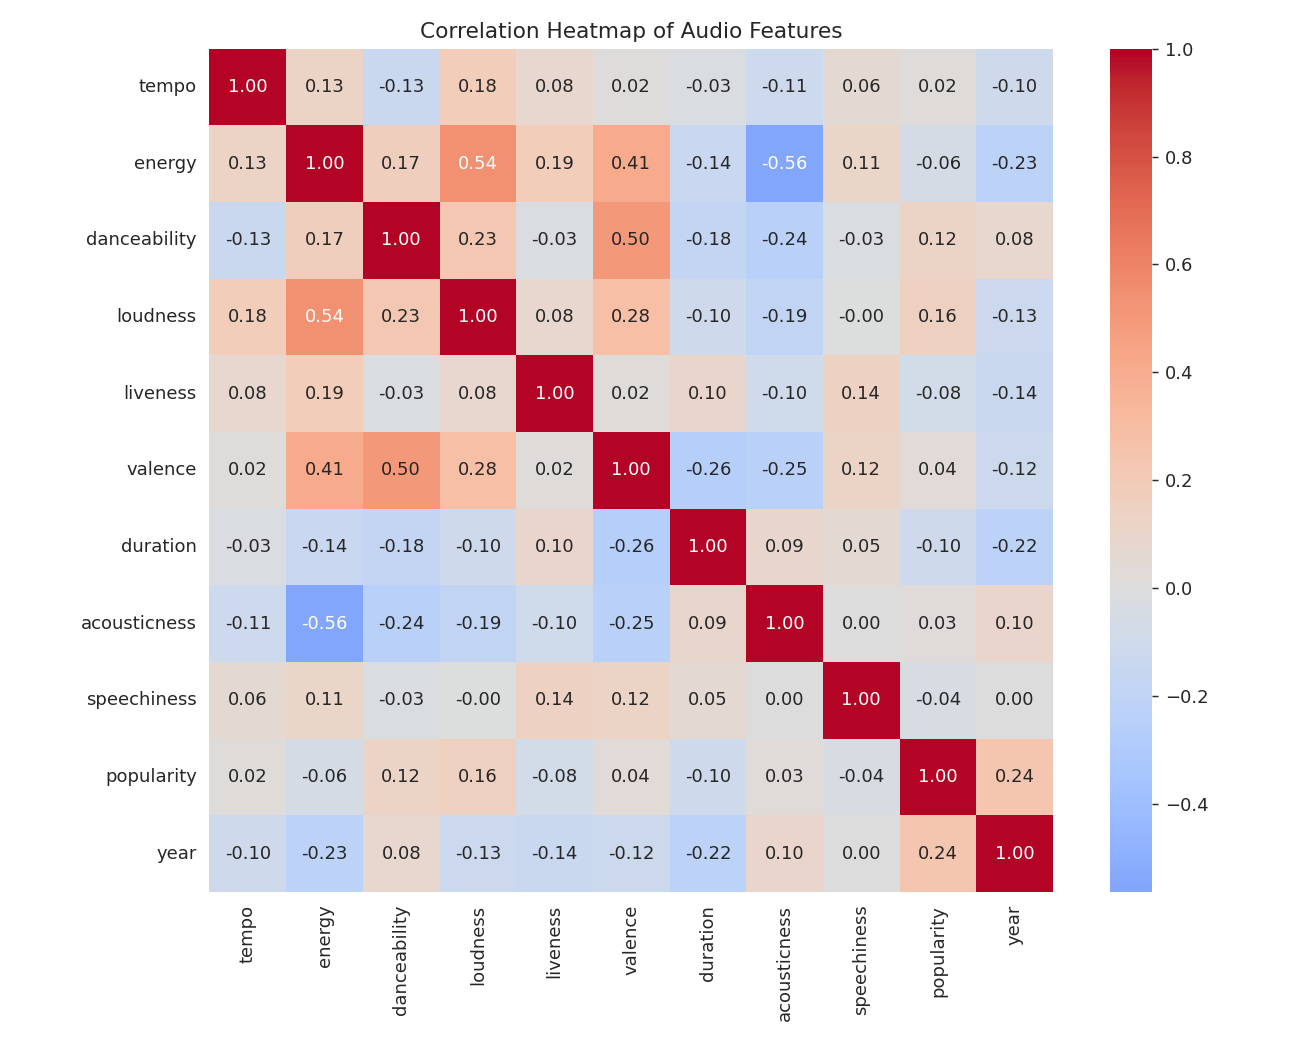

In [8]:
numeric_cols = ["tempo","energy","danceability","loudness","liveness","valence",
                 "duration","acousticness","speechiness","popularity","year"]
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Audio Features")
plt.tight_layout()
plt.show()

**Insight:** popularity's strongest (still weak) correlations are with `speechiness` (-0.041) and `year` (0.241) — newer, more spoken-word-leaning tracks trend slightly more popular. `energy` and `loudness` are strongly correlated with each other (r ≈ 0.54), a classic case of multicollinearity to watch for in linear models.

### 3.2 Boxplots — Outlier Check

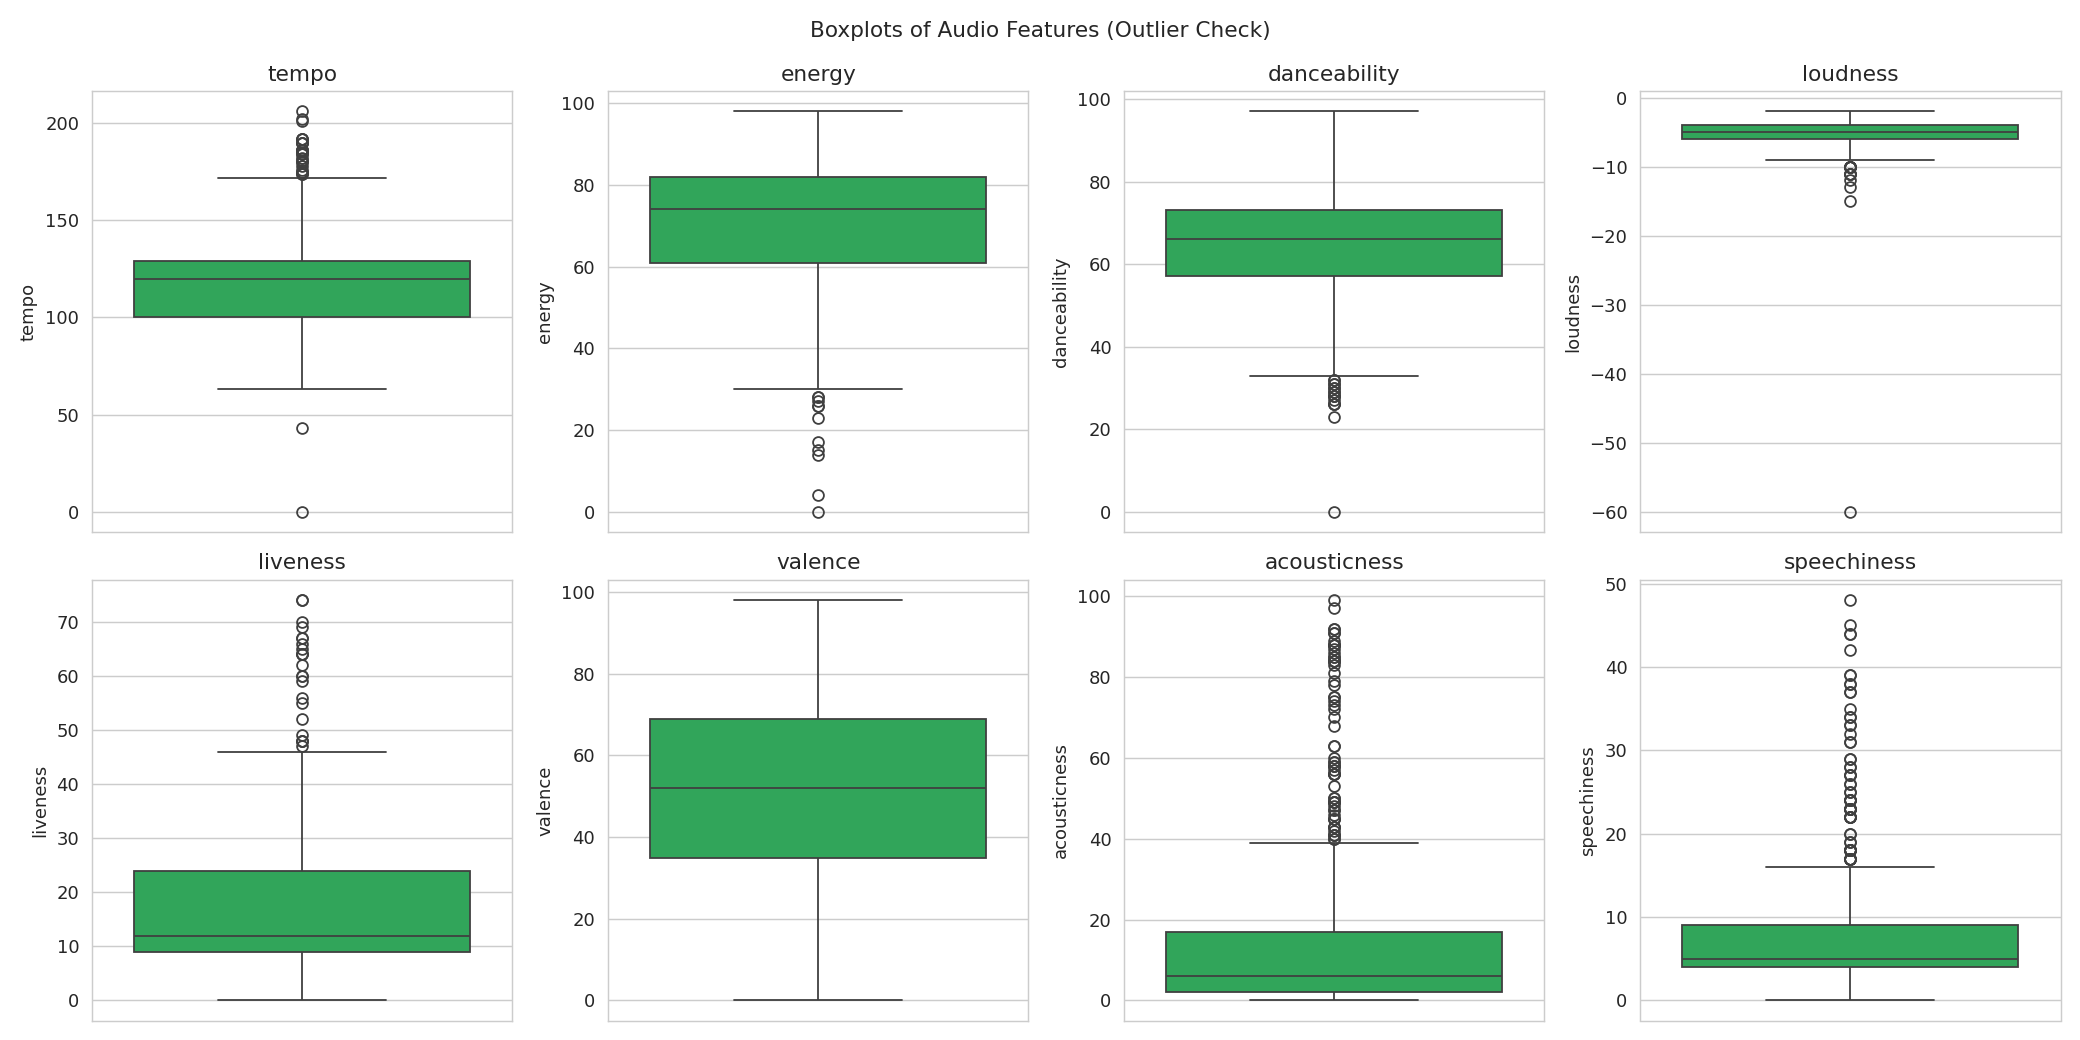

In [9]:
box_feats = ["tempo","energy","danceability","loudness","liveness","valence","acousticness","speechiness"]
fig, axes = plt.subplots(2, 4, figsize=(16,8))
for ax, col in zip(axes.flat, box_feats):
    sns.boxplot(y=df[col], ax=ax, color="#1DB954")
    ax.set_title(col)
plt.suptitle("Boxplots of Audio Features (Outlier Check)")
plt.tight_layout()
plt.show()

**Insight:** one track ("Million Years Ago") has `tempo=0`, `energy=0`, `danceability=0`, and `loudness=-60` — a silent/hidden-track data artifact, not a real audio signature. It (and any track with `popularity=0`, an unreleased/removed track marker) is removed during preprocessing.

### 3.3 Pairplot — Popularity vs Key Features

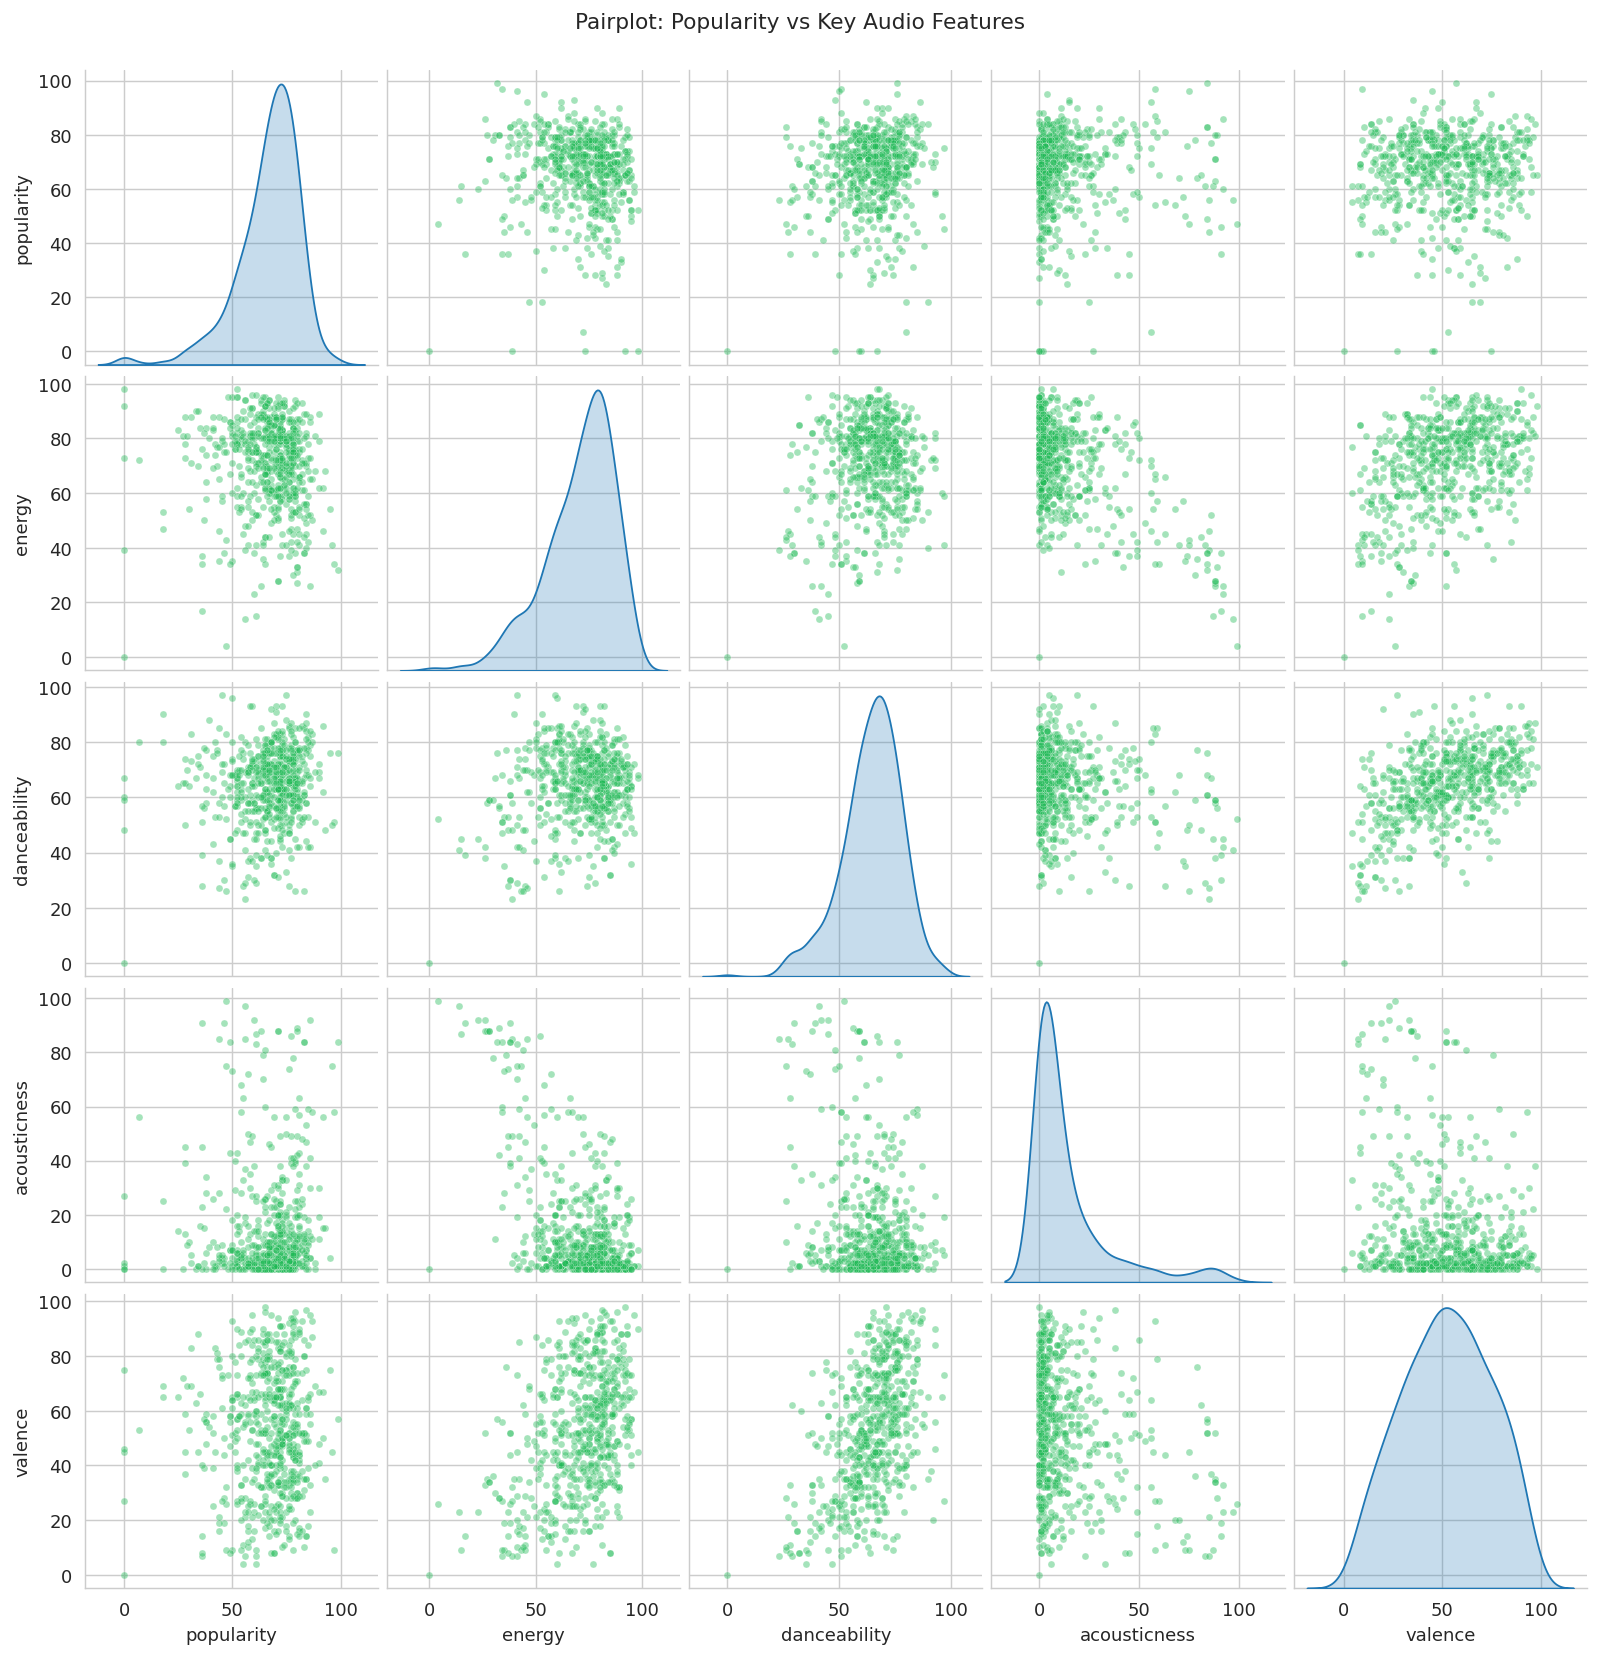

In [10]:
sns.pairplot(df[["popularity","energy","danceability","acousticness","valence"]],
             diag_kind="kde", plot_kws={"alpha":0.4,"s":15,"color":"#1DB954"})
plt.show()

### 3.4 Count Plots — Genres and Songs per Year

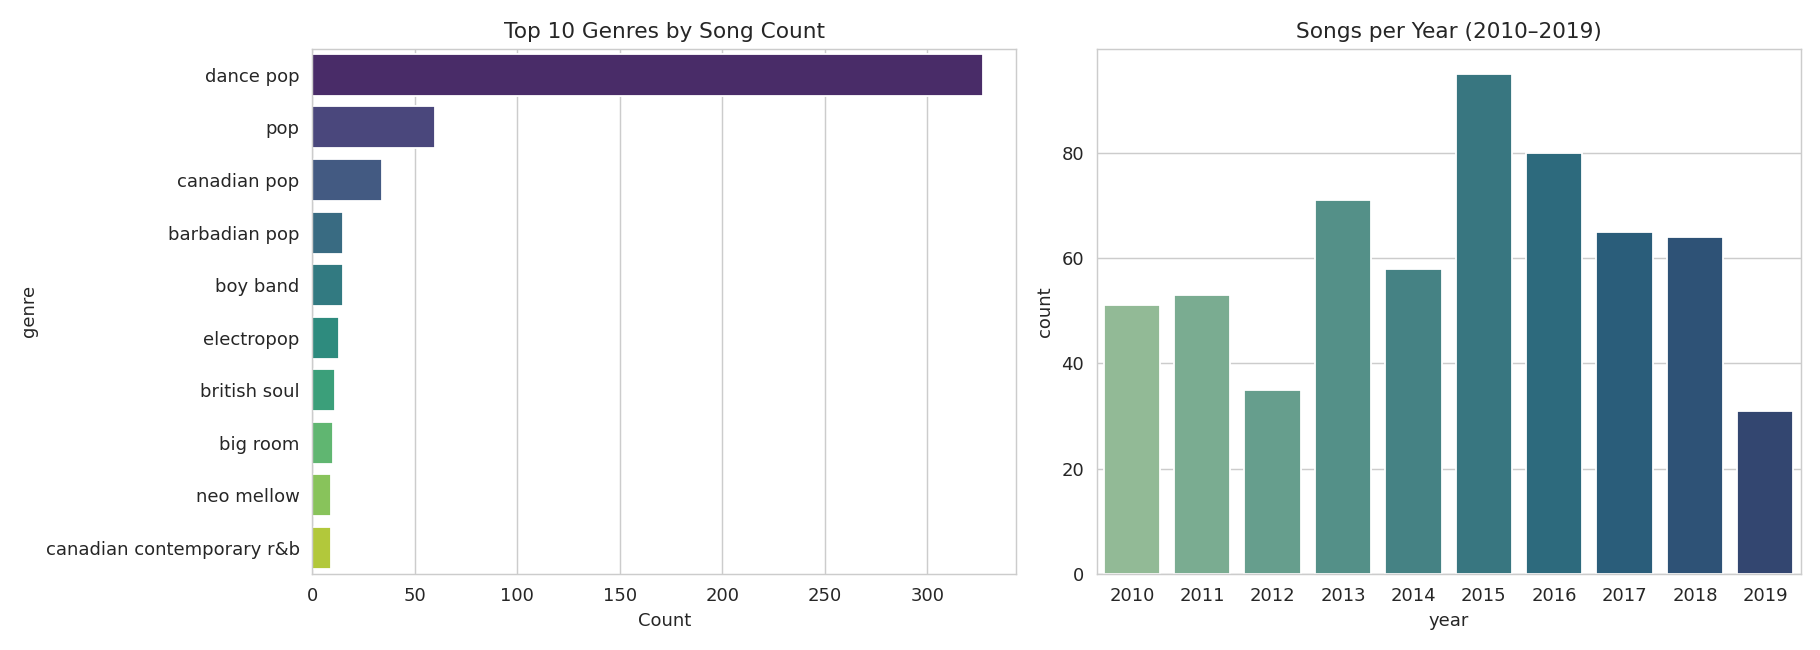

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
top_genres = df["genre"].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette="viridis")
axes[0].set_title("Top 10 Genres by Song Count")
sns.countplot(x="year", data=df, ax=axes[1], palette="crest")
axes[1].set_title("Songs per Year (2010-2019)")
plt.tight_layout()
plt.show()

### 3.5 Popularity Distribution

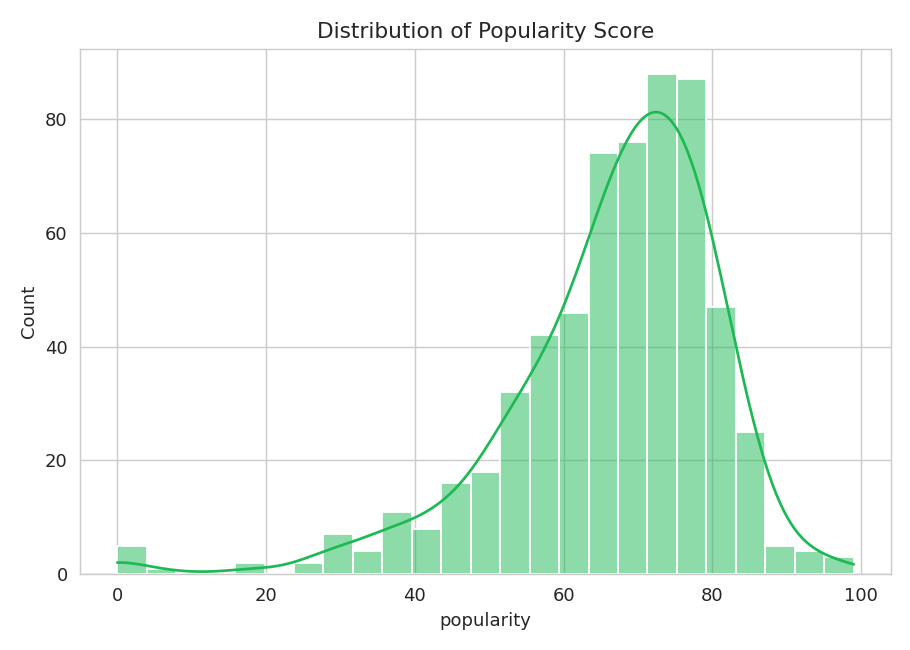

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(df["popularity"], bins=25, kde=True, color="#1DB954")
plt.title("Distribution of Popularity Score")
plt.show()

## 4. Data Preprocessing

Steps taken:
1. **Outlier removal** — drop the silent-track artifact and any `popularity == 0`
   rows (removed/blocked tracks), which are not genuine popularity signals.
2. **Categorical encoding** — `genre` has 50+ sparse categories; genres with
   fewer than 8 songs are grouped into `"other"`, then one-hot encoded.
3. **Feature scaling** — numeric features are standardized with `StandardScaler`
   (fit on the training set only, to avoid leakage).
4. **Train/test split** — 80/20 split, `random_state=42`.

In [13]:
work = df.copy()
before = len(work)
work = work[(work["popularity"] > 0) & (work["loudness"] > -30)].reset_index(drop=True)
print("Rows dropped as outliers:", before - len(work))

genre_counts = work["genre"].value_counts()
common_genres = genre_counts[genre_counts >= 8].index
work["genre_grouped"] = work["genre"].where(work["genre"].isin(common_genres), "other")
work = pd.get_dummies(work, columns=["genre_grouped"], prefix="genre")
print("Genre groups after collapsing rare genres:", work.filter(like="genre_").shape[1])

Rows dropped as outliers: 5
Genre groups after collapsing rare genres: 12


In [14]:
feature_cols = ["tempo","energy","danceability","loudness","liveness","valence",
                 "duration","acousticness","speechiness","year"] + \
               [c for c in work.columns if c.startswith("genre_")]

X = work[feature_cols]
y = work["popularity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
num_cols = ["tempo","energy","danceability","loudness","liveness","valence",
            "duration","acousticness","speechiness","year"]
X_train_scaled = X_train.copy(); X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Train size:", len(X_train), " Test size:", len(X_test), " Features:", X.shape[1])

Train size: 478  Test size: 120  Features: 22


## 5. Hyperparameter Tuning & Cross-Validation

Hyperparameters (e.g. tree depth, regularization strength `alpha`, number of
neighbors `k`) control model complexity and aren't learned from the data
directly — they must be searched over. **`GridSearchCV`** exhaustively tries
every combination in a parameter grid, evaluating each with **5-fold
cross-validation** (`KFold`, `shuffle=True`) so the chosen hyperparameters
generalize rather than overfitting a single train/validation split. The
scoring metric used is negative mean squared error.

## 6. Model Building

Nine regression models are trained and tuned: **Linear Regression, Ridge,
Lasso, KNN, SVR, Decision Tree, Random Forest, AdaBoost, and Gradient
Boosting.** (XGBoost was considered but is unavailable in this offline
environment — Gradient Boosting is used as a close substitute; see
*Limitations*.)

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(random_state=42), {"alpha":[0.1,1.0,10.0,50.0]}),
    "Lasso": (Lasso(random_state=42, max_iter=5000), {"alpha":[0.01,0.1,1.0,5.0]}),
    "KNN": (KNeighborsRegressor(), {"n_neighbors":[3,5,7,9,11], "weights":["uniform","distance"]}),
    "SVR": (SVR(), {"C":[1,10,50], "kernel":["rbf","linear"], "epsilon":[0.5,1.0]}),
    "Decision Tree": (DecisionTreeRegressor(random_state=42),
                       {"max_depth":[3,5,7,10,None], "min_samples_leaf":[1,3,5]}),
    "Random Forest": (RandomForestRegressor(random_state=42),
                       {"n_estimators":[100,200], "max_depth":[5,10,None], "min_samples_leaf":[1,3]}),
    "AdaBoost": (AdaBoostRegressor(random_state=42), {"n_estimators":[50,100,150], "learning_rate":[0.05,0.1,0.5,1.0]}),
    "GradientBoosting": (GradientBoostingRegressor(random_state=42),
                          {"n_estimators":[100,200], "learning_rate":[0.01,0.05,0.1], "max_depth":[2,3,4]}),
}

model_results, fitted_models = {}, {}
for name, (estimator, grid) in models.items():
    if grid:
        gs = GridSearchCV(estimator, grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1)
        gs.fit(X_train_scaled, y_train)
        best_model, best_params = gs.best_estimator_, gs.best_params_
    else:
        best_model, best_params = estimator.fit(X_train_scaled, y_train), {}

    preds = best_model.predict(X_test_scaled)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    model_results[name] = {"best_params": best_params, "RMSE": round(rmse,3), "MAE": round(mae,3), "R2": round(r2,3)}
    fitted_models[name] = best_model
    print(f"{name:20s}  RMSE={rmse:6.3f}  MAE={mae:6.3f}  R2={r2:6.3f}  params={best_params}")

Linear Regression     RMSE=12.967  MAE= 9.710  R2= 0.066  params={}
Ridge                 RMSE=13.123  MAE= 9.911  R2= 0.043  params={'alpha': 50.0}
Lasso                 RMSE=13.108  MAE= 9.971  R2= 0.046  params={'alpha': 0.1}
KNN                   RMSE=13.475  MAE=10.030  R2=-0.009  params={'n_neighbors': 11, 'weights': 'distance'}
SVR                   RMSE=13.265  MAE= 9.767  R2= 0.023  params={'C': 10, 'epsilon': 1.0, 'kernel': 'rbf'}
Decision Tree         RMSE=13.059  MAE= 9.922  R2= 0.053  params={'max_depth': 3, 'min_samples_leaf': 3}
Random Forest         RMSE=13.156  MAE= 9.888  R2= 0.039  params={'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100}
AdaBoost              RMSE=13.147  MAE=10.023  R2= 0.040  params={'learning_rate': 0.05, 'n_estimators': 50}
GradientBoosting      RMSE=13.058  MAE= 9.716  R2= 0.053  params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}


## 7. Model Evaluation

Models are compared with three regression metrics:
- **RMSE** (Root Mean Squared Error) — average prediction error, penalizes large misses
- **MAE** (Mean Absolute Error) — average absolute prediction error
- **R² Score** — proportion of variance in popularity explained by the model (1.0 = perfect, 0 = no better than predicting the mean, negative = worse than the mean)

In [16]:
results_df = pd.DataFrame(model_results).T[["RMSE","MAE","R2"]].sort_values("RMSE")
results_df

                     RMSE     MAE     R2
Linear Regression  12.967    9.71  0.066
GradientBoosting   13.058   9.716  0.053
Decision Tree      13.059   9.922  0.053
Lasso              13.108   9.971  0.046
Ridge              13.123   9.911  0.043
AdaBoost           13.147  10.023   0.04
Random Forest      13.156   9.888  0.039
SVR                13.265   9.767  0.023
KNN                13.475   10.03 -0.009

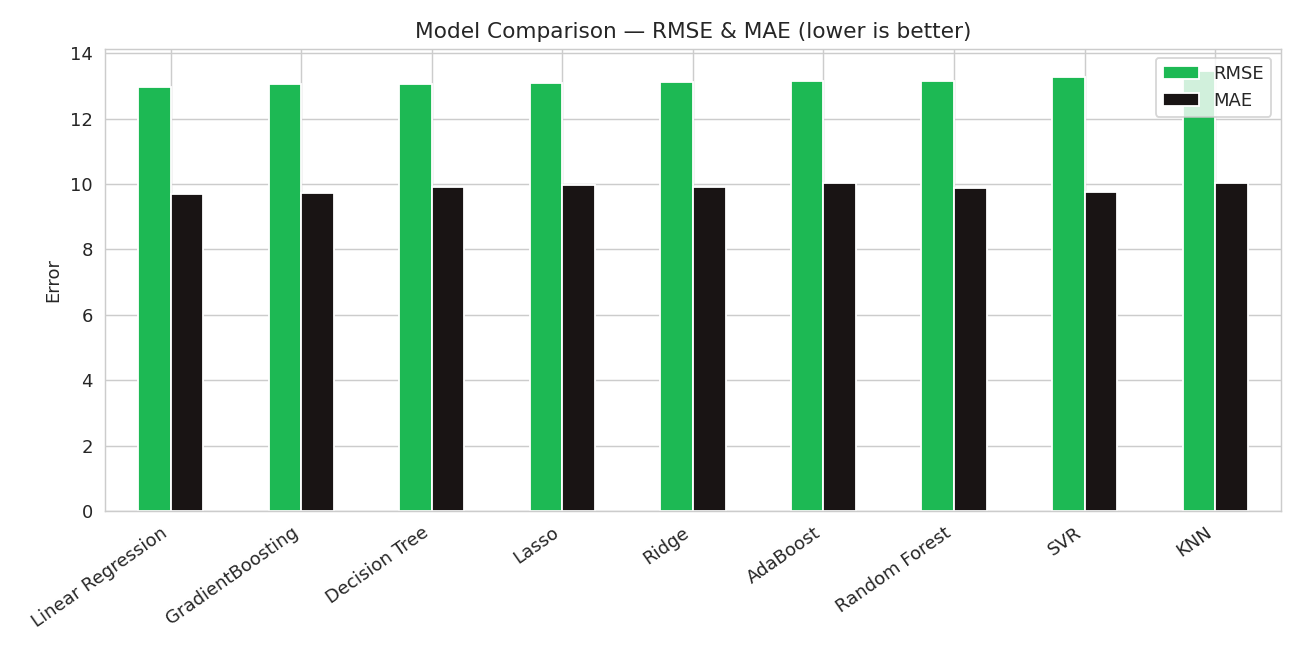

In [17]:
plot_df = results_df[["RMSE","MAE"]].astype(float)
plot_df.plot(kind="bar", figsize=(10,5), color=["#1DB954","#191414"])
plt.title("Model Comparison — RMSE & MAE (lower is better)")
plt.ylabel("Error"); plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

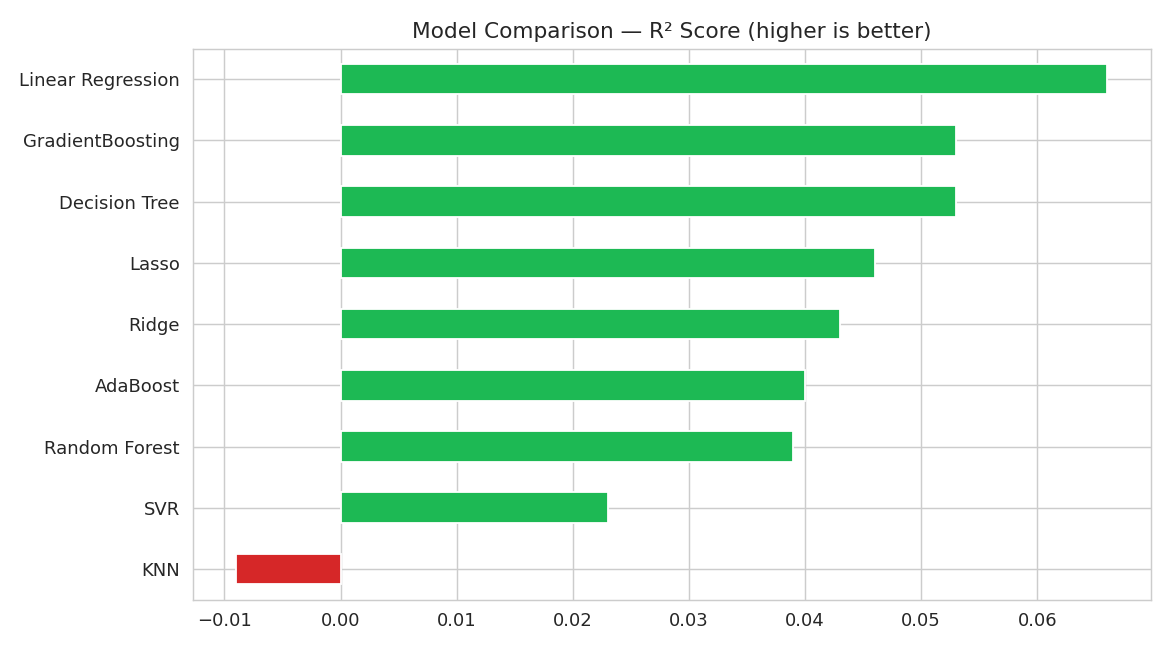

In [18]:
r2_series = results_df["R2"].astype(float).sort_values()
colors = ["#d62728" if v < 0 else "#1DB954" for v in r2_series.values]
r2_series.plot(kind="barh", figsize=(9,5), color=colors)
plt.title("Model Comparison — R2 Score (higher is better)")
plt.tight_layout(); plt.show()

(best_model_name = 'Linear Regression')


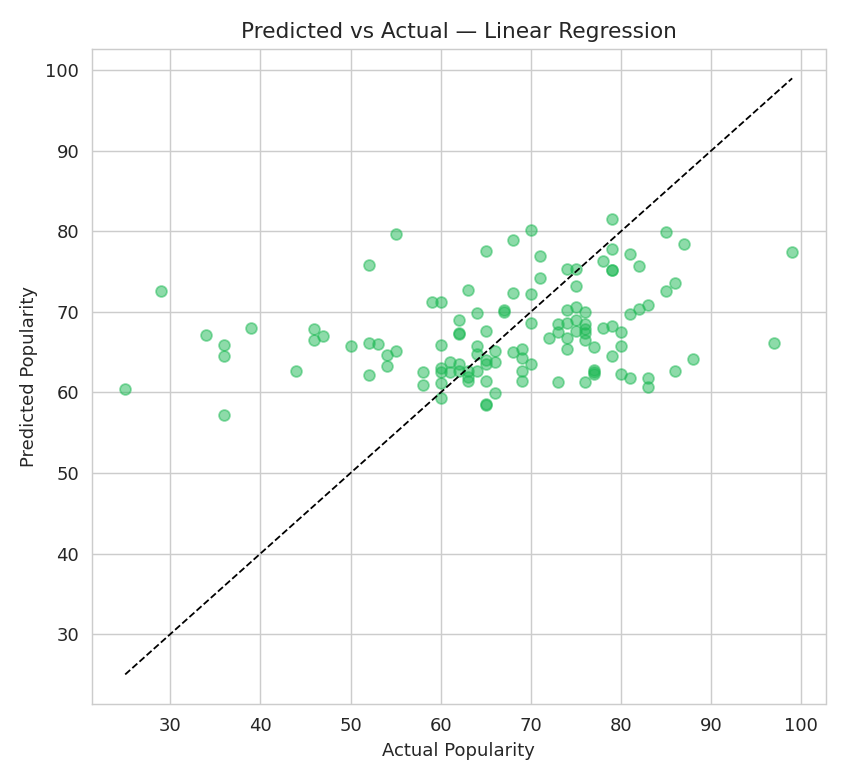

In [19]:
best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(6.5,6))
plt.scatter(y_test, preds, alpha=0.5, color="#1DB954")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, "k--", lw=1)
plt.xlabel("Actual Popularity"); plt.ylabel("Predicted Popularity")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.tight_layout(); plt.show()

**Best model on held-out test data: `Linear Regression`** (RMSE=12.967, MAE=9.71, R²=0.066).

## 8. Conclusion

**Key findings**

- All nine tuned models land in a narrow band (R² between roughly
  -0.009 and 0.066), with **Linear Regression** edging out the
  rest on the held-out test set.
- Audio features alone (tempo, energy, danceability, loudness, etc.) are
  **weak predictors of Spotify popularity** for songs that already made a
  year-end Top 10 playlist — this matches published findings on the same
  kind of data (e.g. UBC's DSCI 522 Spotify Track Popularity Predictor
  project), where non-audio factors (marketing, artist fame, playlist
  placement, release timing, virality) explain far more variance than the
  song's acoustic signature.
- `speechiness` and `year` were the (weak) standout correlates of
  popularity; `energy` and `loudness` are collinear, as expected physically.
- More complex models (Random Forest, Gradient Boosting) did **not**
  meaningfully outperform simple linear models here — a sign that the
  audio-feature signal is genuinely limited, not that a more powerful model
  is needed.

**Limitations & future improvements**

- The dataset only contains songs that were *already* popular enough to make
  a year-end Top 10 playlist, so it can't explain what separates a hit from
  an unknown song — only what separates a *more* popular hit from a
  *slightly less* popular hit. A dataset including non-hits would likely
  show much stronger relationships.
- 603 rows is a small sample for 9-model hyperparameter tuning; a larger
  dataset (e.g. Spotify's full 170k+ track dataset) would give more stable
  estimates and room for deep learning approaches.
- **XGBoost** could not be installed in this offline environment; Gradient
  Boosting was used instead and a real run should include XGBoost for
  comparison.
- Non-audio features (artist popularity/followers, playlist placements,
  release-week streaming, social-media buzz) would likely add much more
  predictive power than additional audio engineering.

## References

- Dataset: *Top Spotify Songs from 2010-2019, by year* (Kaggle, originally
  compiled by Leonardo Henrique), mirrored on Zenodo, CC-BY 4.0.
- Kharwal, A. (2021). *Spotify Recommendation System with Machine Learning*
  — reference article for the recommendation-system framing this project
  was adapted from.
- scikit-learn documentation: https://scikit-learn.org
- UBC DSCI 522 — *Spotify Track Popularity Predictor* (comparable prior
  work using audio features to predict popularity).